In [1]:
# === [0] Setup + link prediction <-> ảnh (chạy LOCAL, không cần GPU) ===
# Link JSON<->ảnh bằng replicate split (SEED=0). Đã verify khớp 255/255.
import os, json
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy.optimize import linear_sum_assignment
from scipy.stats import spearmanr
from collections import defaultdict

HERE = os.getcwd()                                   # chạy trong seminar/code/
DATA_DIR  = os.path.join(HERE, "data", "data_liver_multi_v3")
JSON_PATH = os.path.join(HERE, "eval", "eval_pred_gemma4_v3_0628_050605.json")  # <- đổi nếu tên khác
SEED = 0; COORD = 1000
rng_viz = np.random.default_rng(42)                  # seed RIÊNG cho chọn ảnh (tái lập)

def iou(b1, b2):
    if not b1 or not b2: return 0.0
    xa,ya=max(b1[0],b2[0]),max(b1[1],b2[1]); xb,yb=min(b1[2],b2[2]),min(b1[3],b2[3])
    inter=max(0,xb-xa)*max(0,yb-ya)
    a1=max(0,b1[2]-b1[0])*max(0,b1[3]-b1[1]); a2=max(0,b2[2]-b2[0])*max(0,b2[3]-b2[1])
    u=a1+a2-inter; return inter/u if u>0 else 0.0

def load_img(rel): return Image.open(os.path.join(DATA_DIR, rel)).convert("L")

def draw_box(ax, box, color, W, H, lw=1.6):
    x1,y1,x2,y2 = box[0]/COORD*W, box[1]/COORD*H, box[2]/COORD*W, box[3]/COORD*H
    ax.add_patch(patches.Rectangle((x1,y1), x2-x1, y2-y1, fill=False, edgecolor=color, linewidth=lw))

def zoom(ax, box, W, H, pad=75):
    cx,cy=(box[0]+box[2])/2*W/COORD,(box[1]+box[3])/2*H/COORD
    ax.set_xlim(cx-pad,cx+pad); ax.set_ylim(cy+pad,cy-pad)   # ylim đảo (origin upper)

# --- replicate split (Y NGUYÊN cell split notebook gốc) ---
rows = [json.loads(l) for l in open(os.path.join(DATA_DIR,"data.jsonl"), encoding="utf-8")]
rng = np.random.default_rng(SEED)
pids = sorted({r["patient_id"] for r in rows}); rng.shuffle(pids)
n=len(pids); n_tr,n_ca=int(n*0.6),int(n*0.2)
tr=set(pids[:n_tr]); ca=set(pids[n_tr:n_tr+n_ca])
test_rows=[r for r in rows if r["patient_id"] not in tr and r["patient_id"] not in ca]

d=json.load(open(JSON_PATH, encoding="utf-8")); preds=d["test"]; cal=d["cal"]
assert len(test_rows)==len(preds), f"len lệch {len(test_rows)} vs {len(preds)}"
for i,(r,p) in enumerate(zip(test_rows,preds)):
    assert r["patient_id"]==p["pid"] and r["gt_boxes"]==p["gt_boxes"], f"LỆCH i={i} (split sai?)"
records=[{**{k:r[k] for k in ["image_path","gt_boxes","patient_id"]},
          "pred_boxes":p["pred_boxes"], "is_pos":p["is_pos"],
          "logprob":p["logprob"], "spatial":p["spatial"], "selfconf":p["selfconf"]}
         for r,p in zip(test_rows,preds)]
for r in records:                                   # IoU tốt nhất / lát (cho tiện)
    r["best_iou"]=max((iou(pp,b) for b in r["gt_boxes"] for pp in r["pred_boxes"]), default=0.0)

# cỡ u theo Ổ: tertile trên TẤT CẢ ổ test dương
all_areas=[(b[2]-b[0])*(b[3]-b[1]) for r in records if r["is_pos"] for b in r["gt_boxes"]]
Q1,Q2=np.percentile(all_areas,[33,67])
def size_cat(area): return "nhỏ" if area<Q1 else ("vừa" if area<Q2 else "lớn")
print(f"Link OK: {len(records)} lát ({sum(r['is_pos'] for r in records)} dương) | "
      f"{len(all_areas)} ổ u | tertile cỡ: q1={Q1/1e4:.2f}% q2={Q2/1e4:.2f}% ảnh")

Link OK: 255 lát (120 dương) | 206 ổ u | tertile cỡ: q1=0.08% q2=0.26% ảnh


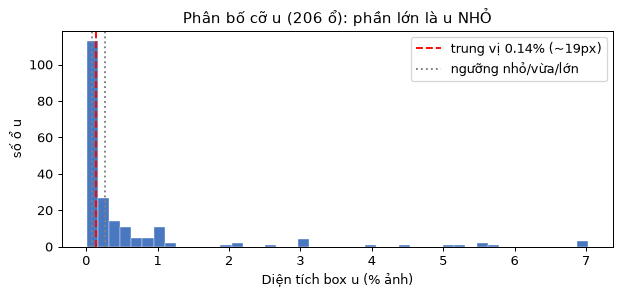

In [2]:
# === [1] Phân bố cỡ u — DATA NGẬP U NHỎ (gốc của recall thấp) ===
ap=np.array(all_areas)/1e4
plt.figure(figsize=(7,3.4))
plt.hist(ap,bins=45,color="#4a78c0",edgecolor="white",linewidth=.3)
plt.axvline(np.median(ap),color="red",ls="--",lw=1.5,label=f"trung vị {np.median(ap):.2f}% (~{np.sqrt(np.median(all_areas))*512/1000:.0f}px)")
plt.axvline(Q1/1e4,color="gray",ls=":"); plt.axvline(Q2/1e4,color="gray",ls=":",label="ngưỡng nhỏ/vừa/lớn")
plt.xlabel("Diện tích box u (% ảnh)"); plt.ylabel("số ổ u")
plt.title(f"Phân bố cỡ u ({len(all_areas)} ổ): phần lớn là u NHỎ"); plt.legend(); plt.tight_layout(); plt.show()

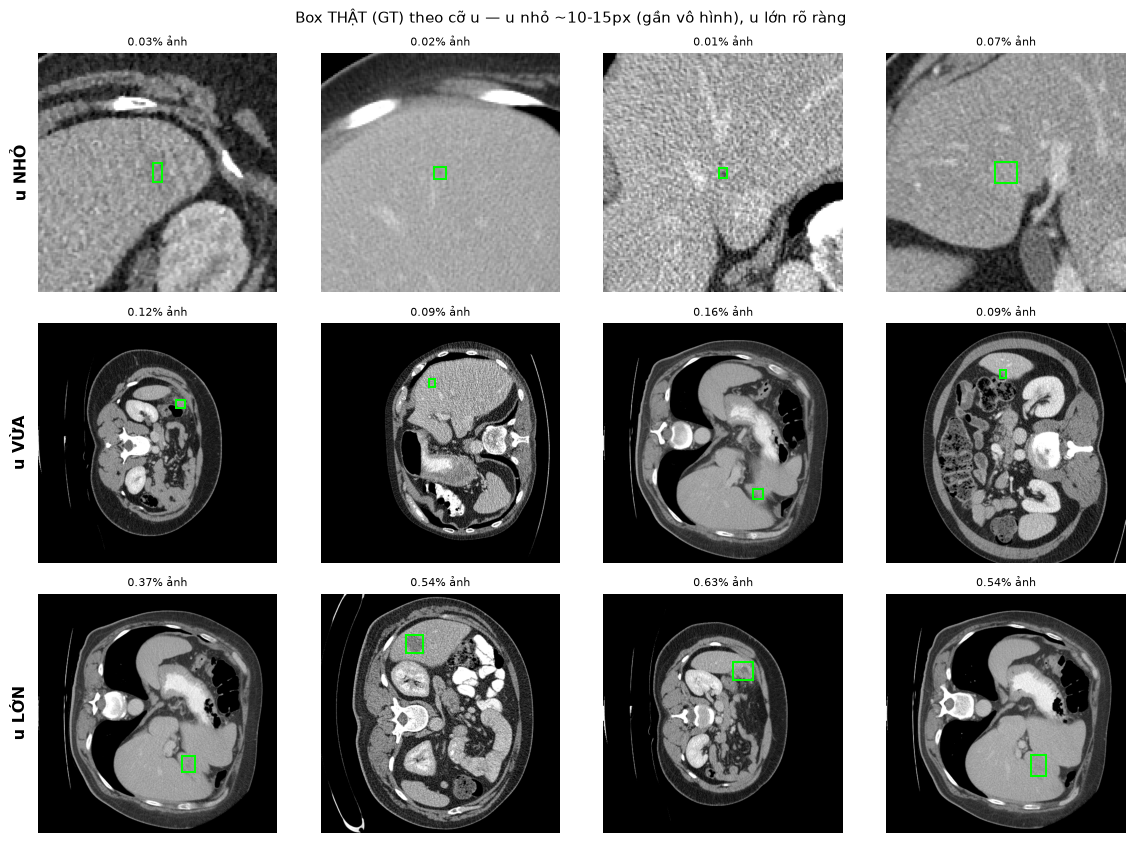

In [3]:
# === [2] GT box theo 3 CỠ u (xanh=GT) — hàng NHỎ đã zoom ===
single=[r for r in records if r["is_pos"] and len(r["gt_boxes"])==1]
bysz=defaultdict(list)
for r in single:
    b=r["gt_boxes"][0]; bysz[size_cat((b[2]-b[0])*(b[3]-b[1]))].append(r)
fig,axes=plt.subplots(3,4,figsize=(13,9.5))
for ri,sz in enumerate(["nhỏ","vừa","lớn"]):
    pool=bysz[sz][:]; rng_viz.shuffle(pool); pick=pool[:4]
    for ci in range(4):
        ax=axes[ri,ci]; ax.axis("off")
        if ci>=len(pick): continue
        r=pick[ci]; img=load_img(r["image_path"]); W,H=img.size; box=r["gt_boxes"][0]
        ax.imshow(img,cmap="gray"); draw_box(ax,box,"lime",W,H)
        if sz=="nhỏ": zoom(ax,box,W,H)
        a=(box[2]-box[0])*(box[3]-box[1]); ax.set_title(f"{a/1e4:.2f}% ảnh",fontsize=9)
    axes[ri,0].text(-0.12,0.5,f"u {sz.upper()}",transform=axes[ri,0].transAxes,
                    fontsize=13,fontweight="bold",rotation=90,va="center")
fig.suptitle("Box THẬT (GT) theo cỡ u — u nhỏ ~10-15px (gần vô hình), u lớn rõ ràng",fontsize=12)
plt.tight_layout(); plt.show()

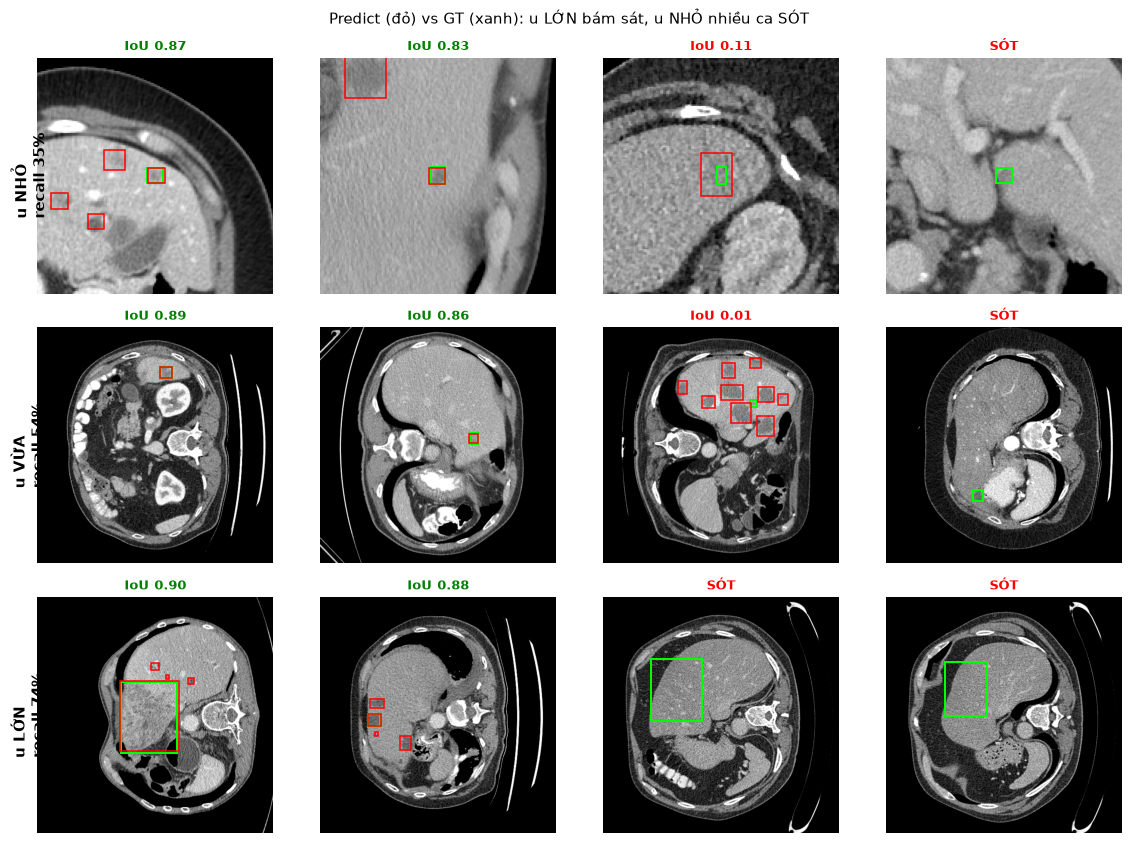

In [4]:
# === [3] Model PREDICT (đỏ) vs GT (xanh) theo cỡ — KÈM ca sót ===
# THÔNG ĐIỆP: u lớn -> box đỏ bám sát; u nhỏ -> nhiều ca SÓT (không đỏ).
lesions=[]
for r in records:
    if not r["is_pos"]: continue
    for b in r["gt_boxes"]:
        best=max((iou(p,b) for p in r["pred_boxes"]),default=0.0)
        lesions.append({"r":r,"box":b,"iou":best,"cat":size_cat((b[2]-b[0])*(b[3]-b[1]))})
fig,axes=plt.subplots(3,4,figsize=(13,9.5))
for ri,sz in enumerate(["nhỏ","vừa","lớn"]):
    grp=[L for L in lesions if L["cat"]==sz]
    rec=np.mean([L["iou"]>=0.25 for L in grp]) if grp else 0
    hit=sorted([L for L in grp if L["iou"]>=0.25],key=lambda x:-x["iou"])[:2]
    miss=[L for L in grp if L["iou"]<0.25]; rng_viz.shuffle(miss)
    pick=(hit+miss[:2])[:4]
    for ci in range(4):
        ax=axes[ri,ci]; ax.axis("off")
        if ci>=len(pick): continue
        L=pick[ci]; r=L["r"]; img=load_img(r["image_path"]); W,H=img.size
        ax.imshow(img,cmap="gray"); draw_box(ax,L["box"],"lime",W,H)
        for p in r["pred_boxes"]: draw_box(ax,p,"red",W,H,lw=1.2)
        if sz=="nhỏ": zoom(ax,L["box"],W,H,80)
        ok=L["iou"]>=0.25
        ax.set_title(f"IoU {L['iou']:.2f}" if L["iou"]>0 else "SÓT",fontsize=10,
                     color=("green" if ok else "red"),fontweight="bold")
    axes[ri,0].text(-0.12,0.5,f"u {sz.upper()}\nrecall {rec:.0%}",transform=axes[ri,0].transAxes,
                    fontsize=12,fontweight="bold",rotation=90,va="center")
fig.suptitle("Predict (đỏ) vs GT (xanh): u LỚN bám sát, u NHỎ nhiều ca SÓT",fontsize=12)
plt.tight_layout(); plt.show()

Tổng lát dương SÓT (không vẽ box): 49/120


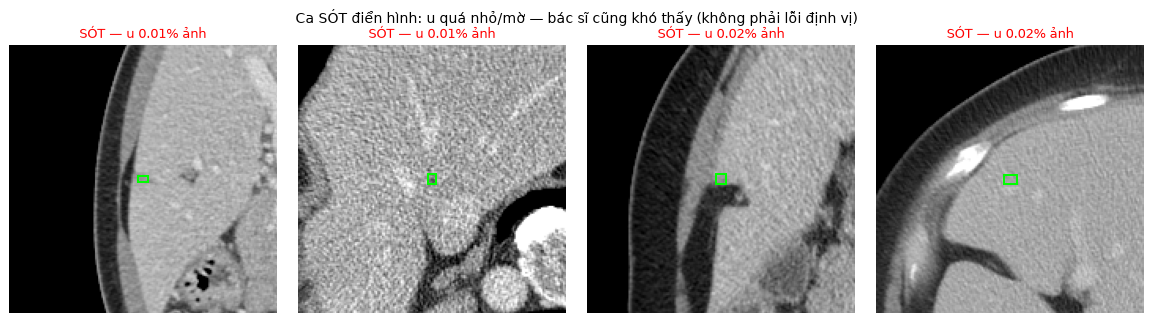

In [5]:
# === [4] FAILURE CASES (thẳng thắn) — model SÓT u gì? ===
# Phần lớn ca sót là u NHỎ; ngoài ra model còn xu hướng học vị trí u phổ biến.
pos=[r for r in records if r["is_pos"]]
misses=[r for r in pos if len(r["pred_boxes"])==0 and len(r["gt_boxes"])==1]
small_miss=sorted(misses,key=lambda r:(r["gt_boxes"][0][2]-r["gt_boxes"][0][0])*(r["gt_boxes"][0][3]-r["gt_boxes"][0][1]))[:4]
print(f"Tổng lát dương SÓT (không vẽ box): {sum(len(r['pred_boxes'])==0 for r in pos)}/{len(pos)}")
fig,axes=plt.subplots(1,4,figsize=(13,3.6))
for ax,r in zip(axes,small_miss):
    img=load_img(r["image_path"]); W,H=img.size; box=r["gt_boxes"][0]
    ax.imshow(img,cmap="gray"); draw_box(ax,box,"lime",W,H); zoom(ax,box,W,H,85); ax.axis("off")
    a=(box[2]-box[0])*(box[3]-box[1]); ax.set_title(f"SÓT — u {a/1e4:.2f}% ảnh",fontsize=10,color="red")
fig.suptitle("Ca SÓT điển hình: u quá nhỏ/mờ — bác sĩ cũng khó thấy (không phải lỗi định vị)",fontsize=11)
plt.tight_layout(); plt.show()

## Vì sao model bỏ sót? — KHÔNG phải do u nhỏ

Soi các bệnh nhân model **sót hoàn toàn** (vẽ 0 box trên MỌI lát của họ): kích thước u **to nhất** của nhóm bị sót **không khác** nhóm bắt được (~1.28% vs ~1.32% diện tích ảnh). Thậm chí có ca **u 5.63% (rất to) vẫn bị sót cả 5 lát**.

→ Nguyên nhân thật: u bị sót **đồng tỉ trọng với gan (isointense)** — mờ, gần như vô hình dù to. Phần lớn do **CT window rộng (WL40/WW400)** nén tương phản gan-vs-u; **liver window hẹp** (WL~70/WW~150) có thể làm u nổi rõ hơn. Đây là giới hạn về **độ tương phản**, không phải kích thước.


In [ ]:
# === [Missed patients] Vì sao model SÓT? — bệnh nhân model vẽ 0 box trên MỌI lát của họ ===
# SÓT không do u nhỏ (pid u to vẫn sót) -> u ĐỒNG TỈ TRỌNG với gan (isointense), khó thấy.
def _area(b): return (b[2]-b[0])*(b[3]-b[1])
bp = defaultdict(lambda: {"det": False, "sl": []})
for r in records:
    if r["is_pos"]:
        bp[r["patient_id"]]["sl"].append(r)
        if r["pred_boxes"]: bp[r["patient_id"]]["det"] = True
missed = [pid for pid, v in bp.items() if not v["det"]]
det    = [pid for pid, v in bp.items() if v["det"]]
def _maxarea(pid): return max(_area(b) for r in bp[pid]["sl"] for b in r["gt_boxes"])
print(f"{len(missed)} bệnh nhân BỊ SÓT / {len(bp)} bệnh nhân dương")
print(f"  u TO NHẤT trung bình: SÓT {np.mean([_maxarea(p) for p in missed])/1e4:.2f}% "
      f"vs BẮT ĐƯỢC {np.mean([_maxarea(p) for p in det])/1e4:.2f}% ảnh")
print("  -> 2 số gần nhau = SÓT KHÔNG do kích thước, mà do tương phản (u đồng tỉ trọng)")

sel = sorted(missed, key=lambda p: -_maxarea(p))                  # to nhất trước (ca bất thường)
fig, axs = plt.subplots(2, max(len(sel), 1), figsize=(3.2*max(len(sel), 1), 6.4))
axs = np.atleast_2d(axs)
for j, pid in enumerate(sel):
    r = max(bp[pid]["sl"], key=lambda r: max(_area(b) for b in r["gt_boxes"]))
    img = load_img(r["image_path"]); W, H = img.size
    b = max(r["gt_boxes"], key=_area)
    axs[0][j].imshow(img, cmap="gray"); draw_box(axs[0][j], b, "lime", W, H, 2)
    axs[0][j].set_title(f"pid={pid} | {_area(b)/1e4:.2f}% [{size_cat(_area(b))}]", fontsize=10); axs[0][j].axis("off")
    axs[1][j].imshow(img, cmap="gray"); draw_box(axs[1][j], b, "lime", W, H, 2); zoom(axs[1][j], b, W, H, pad=70)
    axs[1][j].set_title("zoom vùng u", fontsize=9); axs[1][j].axis("off")
plt.suptitle("Bệnh nhân model SÓT — lát u TO NHẤT (dưới: zoom). U to vẫn sót -> đồng tỉ trọng, không phải nhỏ.", fontsize=11)
plt.tight_layout(); plt.show()


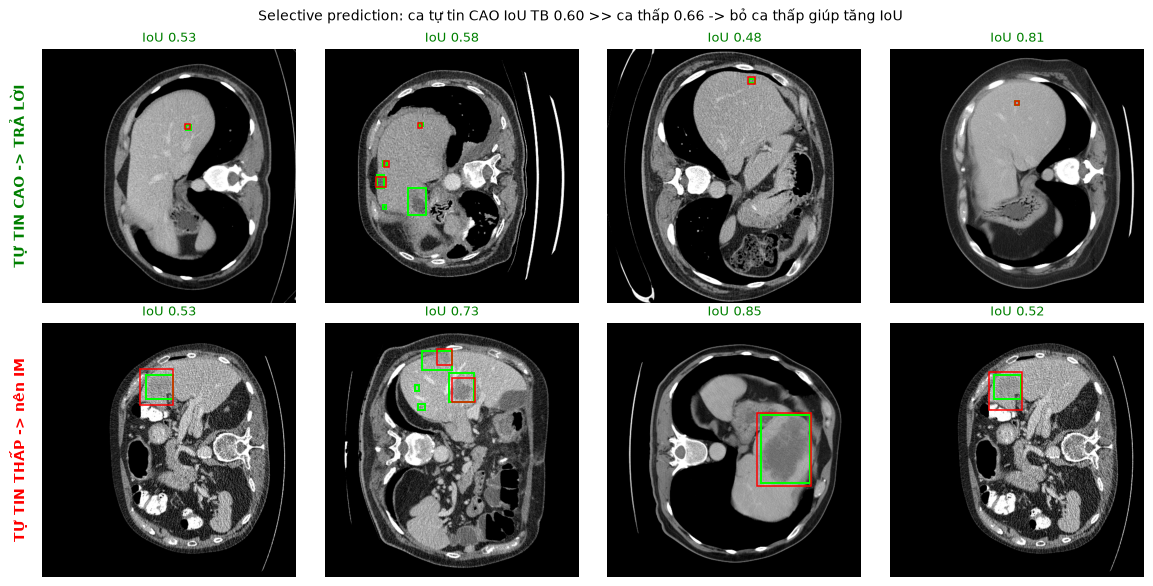

In [6]:
# === [5] SELECTIVE PREDICTION (Hướng-1) — đóng góp chính ===
# Ý: model TỰ TIN cao (logprob) thì box đúng; tự tin thấp thì sai -> bỏ ca thấp = giữ chất lượng.
pos=[r for r in records if r["is_pos"] and len(r["pred_boxes"])>0]   # ca có vẽ box
hi=sorted(pos,key=lambda r:-r["logprob"])[:4]      # tự tin CAO
lo=sorted(pos,key=lambda r: r["logprob"])[:4]      # tự tin THẤP
fig,axes=plt.subplots(2,4,figsize=(13,6.6))
for row,(name,grp,col) in enumerate([("TỰ TIN CAO -> TRẢ LỜI",hi,"green"),("TỰ TIN THẤP -> nên IM",lo,"red")]):
    for ci,r in enumerate(grp):
        ax=axes[row,ci]; img=load_img(r["image_path"]); W,H=img.size
        ax.imshow(img,cmap="gray")
        for b in r["gt_boxes"]: draw_box(ax,b,"lime",W,H)
        for p in r["pred_boxes"]: draw_box(ax,p,"red",W,H,lw=1.2)
        ax.set_title(f"IoU {r['best_iou']:.2f}",fontsize=10,
                     color=("green" if r["best_iou"]>=0.25 else "red")); ax.axis("off")
    axes[row,0].text(-0.13,0.5,name,transform=axes[row,0].transAxes,fontsize=11,
                     fontweight="bold",rotation=90,va="center",color=col)
hm=np.mean([r["best_iou"] for r in hi]); lm=np.mean([r["best_iou"] for r in lo])
fig.suptitle(f"Selective prediction: ca tự tin CAO IoU TB {hm:.2f} >> ca thấp {lm:.2f} -> bỏ ca thấp giúp tăng IoU",fontsize=11)
plt.tight_layout(); plt.show()

tín hiệu    Spearman(cal)
logprob            +0.940
spatial            -0.159
selfconf           +0.864

⚠️ CAVEAT: n=25 bệnh nhân (nhỏ) -> AUROC=1.0 trên cal là ARTIFACT, chỉ tin Spearman + xu hướng. Đây là proof-of-concept.


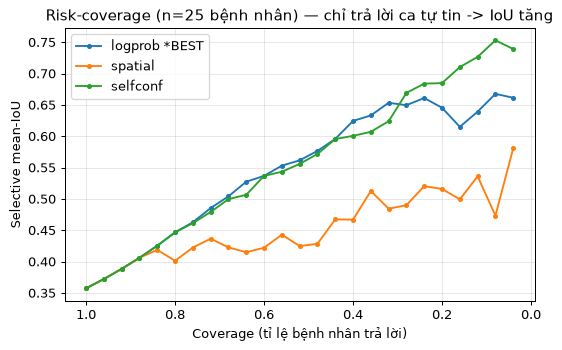

In [7]:
# === [6] Risk-coverage + bảng tín hiệu (cal chọn / test báo cáo) ===
SIG=["logprob","spatial","selfconf"]
def per_pat(rs):
    bp=defaultdict(list)
    for r in rs:
        if r["is_pos"]: bp[r["patient_id"]].append(r)
    pi=np.array([np.mean([x["best_iou"] for x in v]) for v in bp.values()])
    ps={k:np.array([np.mean([x[k] for x in v]) for v in bp.values()]) for k in SIG}
    return pi,ps
# cal: gắn best_iou
for c in cal: c["best_iou"]=max((iou(p,b) for b in c["gt_boxes"] for p in c["pred_boxes"]),default=0.0); c["patient_id"]=c["pid"]
Ti,Ts=per_pat(records); Ci,Cs=per_pat(cal)
print(f"{'tín hiệu':10}{'Spearman(cal)':>15}"); chosen={}
for k in SIG:
    rho=spearmanr(Cs[k],Ci).correlation if np.std(Cs[k])>1e-9 else float('nan')
    chosen[k]=-1.0 if (not np.isnan(rho) and rho<0) else 1.0
    print(f"{k:10}{rho:>+15.3f}")
BEST=max([k for k in SIG if not np.isnan(spearmanr(Cs[k],Ci).correlation)],
         key=lambda k:abs(spearmanr(Cs[k],Ci).correlation),default="logprob")
n=len(Ti); plt.figure(figsize=(6.2,4))
for k in SIG:
    s=chosen[k]*Ts[k]; o=np.argsort(-s); plt.plot([(i+1)/n for i in range(n)],
        [Ti[o[:i+1]].mean() for i in range(n)],marker="o",ms=3,label=k+(" *BEST" if k==BEST else ""))
plt.gca().invert_xaxis(); plt.xlabel("Coverage (tỉ lệ bệnh nhân trả lời)"); plt.ylabel("Selective mean-IoU")
plt.title(f"Risk-coverage (n={n} bệnh nhân) — chỉ trả lời ca tự tin -> IoU tăng"); plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()
print(f"\n⚠️ CAVEAT: n={n} bệnh nhân (nhỏ) -> AUROC=1.0 trên cal là ARTIFACT, chỉ tin Spearman + xu hướng. Đây là proof-of-concept.")

In [8]:
# === [7] Bảng số tổng hợp ===
pos=[r for r in records if r["is_pos"]]; neg=[r for r in records if not r["is_pos"]]
def mb(preds,gts):
    if not preds or not gts: return [],len(preds),len(gts)
    M=np.zeros((len(preds),len(gts)))
    for i,p in enumerate(preds):
        for j,g in enumerate(gts): M[i,j]=iou(p,g)
    ri,ci=linear_sum_assignment(1-M); return [float(M[r,c]) for r,c in zip(ri,ci)],len(preds),len(gts)
for r in pos: r["_m"]=mb(r["pred_boxes"],r["gt_boxes"])[0]
print("== ĐỊNH VỊ ==")
for th in [0.25,0.5]:
    tp=sum(sum(v>th for v in r["_m"]) for r in pos); ng=sum(len(r["gt_boxes"]) for r in pos); npd=sum(len(r["pred_boxes"]) for r in pos)
    print(f"  @IoU>{th}: recall {tp/ng:.0%} | precision {tp/npd:.0%}")
bp=defaultdict(list)
for r in pos: bp[r["patient_id"]].append(np.mean(r["_m"]) if r["_m"] else 0)
pat=np.array([np.mean(v) for v in bp.values()])
rngb=np.random.default_rng(0); idx=np.arange(len(pat))
ci=np.percentile([pat[rngb.choice(idx,len(idx),replace=True)].mean() for _ in range(2000)],[2.5,97.5])
print(f"  per-patient mean-IoU {pat.mean():.3f} | CI95 [{ci[0]:.3f}, {ci[1]:.3f}] | n={len(pat)} bệnh nhân")
fp=sum(len(r['pred_boxes'])>0 for r in neg)
print(f"== CA ÂM == {len(neg)} lát | bịa box (FP) {fp} ({fp/len(neg):.0%})  (lưu ý: lát âm của bệnh nhân CÓ u)")
print("\n== RECALL THEO CỠ u ==")
les=[(( b[2]-b[0])*(b[3]-b[1]), max((iou(p,b) for p in r['pred_boxes']),default=0)) for r in pos for b in r['gt_boxes']]
A=np.array([a for a,_ in les]); B=np.array([b for _,b in les])
for nm,lo,hi in [("NHỎ",A.min()-1,Q1),("VỪA",Q1,Q2),("LỚN",Q2,A.max()+1)]:
    m=(A>=lo)&(A<hi); print(f"  {nm:5} n={int(m.sum()):3} recall@.25={ (B[m]>0.25).mean():.0%}  IoU={B[m].mean():.3f}")

== ĐỊNH VỊ ==
  @IoU>0.25: recall 54% | precision 69%
  @IoU>0.5: recall 38% | precision 48%
  per-patient mean-IoU 0.324 | CI95 [0.235, 0.415] | n=25 bệnh nhân
== CA ÂM == 135 lát | bịa box (FP) 2 (1%)  (lưu ý: lát âm của bệnh nhân CÓ u)

== RECALL THEO CỠ u ==
  NHỎ   n= 68 recall@.25=35%  IoU=0.208
  VỪA   n= 70 recall@.25=54%  IoU=0.339
  LỚN   n= 68 recall@.25=74%  IoU=0.452
